## 示例一：使用 VarQITE 算法求解分子基态
本节演示如何使用变分量子虚时演化（VarQITE）算法求解 CH4（甲烷）分子的基态能量。

### 导入必要的库

In [ ]:
import os
import torch
import matplotlib.pyplot as plt

from backends.Tensorcircuit import TensorCircuitBackend
from ansatz.HEA import HEAAnsatz
from solvers.var_qite import VarQITESolver
from chemistry.hamiltonian import Hamiltonian

# 设置环境变量，避免某些系统下的 OpenMP 冲突
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# 声明使用的后端类型
os.environ["HYQ_BACKEND"] = "tensorcircuit"

Please first ``pip install -U qiskit`` to enable related functionality in translation module


### 定义分子结构与哈密顿量

### 定义 CH4 分子坐标 
首先定义分子的几何坐标，如果要计算其他分子，将以下坐标替换为其他分子的坐标即可。

In [2]:
ch4_geometry = [
    [0.0, 0.0, 0.0],
    [0.628, 0.628, 0.628],
    [0.628, -0.628, -0.628],
    [-0.628, 0.628, -0.628],
    [-0.628, -0.628, 0.628]]

### 利用 Hamiltonian 类生成对应的量子算符。

In [3]:
# 2. 实例化哈密顿量
h_obj = Hamiltonian(
    symbols=['C', 'H', 'H', 'H', 'H'], 
    geometry=ch4_geometry, 
    charge=0, 
    multiplicity=1
)

>>> [Hamiltonian] 正在调用 Psi4 计算分子积分...


### 使用活性空间（Active Space）近似。

活性空间约化 (2个电子, 2个轨道 -> 4个量子比特)。这将把复杂的问题映射到一个 4-Qubit 的系统上，从而减少了所需的量子比特数。

In [4]:
hamiltonian_list, n_qubits, n_electrons = h_obj.get_processed_hamiltonian(
    n_active_electrons=2, 
    n_active_orbitals=2
)
print(f"任务构建完成: Qubits={n_qubits}, Electrons={n_electrons}")
print(f"哈密顿量项数: {len(hamiltonian_list)}")
print(hamiltonian_list)

>>> [Hamiltonian] 设置活性空间: 2e, 2orb
>>> [Hamiltonian] 原始算符项数: 27
任务构建完成: Qubits=4, Electrons=2
哈密顿量项数: 27
[(-38.67565316015801, 'IIII'), (0.16741488365988957, 'ZIII'), (0.1674148836598896, 'IZII'), (-0.2668902876688517, 'IIZI'), (-0.2668902876688517, 'IIIZ'), (0.13676724242098295, 'ZZII'), (0.007379556143814752, 'XZXI'), (0.007379556143814752, 'YZYI'), (0.10489815847970045, 'ZIZI'), (0.12376996346329175, 'ZIIZ'), (0.12376996346329175, 'IZZI'), (0.007379556143814752, 'IXZX'), (0.007379556143814752, 'IYZY'), (0.10489815847970045, 'IZIZ'), (0.13804363174758946, 'IIZZ'), (-0.001676037399024612, 'ZXZX'), (-0.001676037399024612, 'ZYZY'), (-0.001676037399024612, 'XIXI'), (-0.001676037399024612, 'YIYI'), (-0.01887180498359129, 'XXYY'), (0.01887180498359129, 'XYYX'), (0.01887180498359129, 'YXXY'), (-0.01887180498359129, 'YYXX'), (-0.009055595070773952, 'XZXZ'), (-0.009055595070773952, 'YZYZ'), (-0.009055595070773952, 'IXIX'), (-0.009055595070773952, 'IYIY')]


### 配置量子后端与拟设 (Ansatz)
我们使用 硬件高效拟设 (Hardware Efficient Ansatz) 作为参数化量子线路，并初始化变分参数。

In [5]:
# 初始化后端
backend = TensorCircuitBackend()

# 构建拟设电路，深度为 3
ansatz = HEAAnsatz(n_qubits=n_qubits, depth=3)

# 随机初始化参数 (或指定一组特定参数)
# 这里的参数对应于量子门中的旋转角度
init_params = torch.tensor(
    [-1.0537, -0.0093,  0.1670,  0.2519, -1.1550,  0.0890,  0.4244, -0.4072,
      0.3096,  0.0074,  0.0569, -0.6634, -0.5790,  0.5391,  0.1754,  0.3254],
    dtype=torch.float64
)

print("初始参数形状:", init_params.shape)

初始参数形状: torch.Size([16])


### 执行 VarQITE 演化
启动求解器。  
VarQITE 通过在虚时间轴上演化参数，使系统自然冷却至基态。求解器的可选模式'mode'可以是 'autograd'(自动微分模式) 或'parameter_shift'(参数平移模式)  
total_tau: 演化的总虚时间。  
delta_tau: 每个时间步长。

In [6]:
var_solver = VarQITESolver(backend)

# 执行演化
final_e, final_params, energy_history, _ = var_solver.solve(
    ansatz, 
    init_params, 
    hamiltonian_list, 
    total_tau=10.0, 
    delta_tau=0.05, 
    mode='autograd'
)

print(f"求解结束。最终能量: {energy_history[-1]:.6f} Hartree")

--- VarQITE Start (Mode=autograd, Total Tau=10.0, dt=0.05) ---
Step 0: Energy = -38.718087 (Time: 0.1730s)
Step 10: Energy = -39.150861 (Time: 0.1309s)
Step 20: Energy = -39.466150 (Time: 0.1333s)
Step 30: Energy = -39.615719 (Time: 0.1643s)
Step 40: Energy = -39.678400 (Time: 0.1435s)
Step 50: Energy = -39.705621 (Time: 0.1473s)
Step 60: Energy = -39.718145 (Time: 0.1566s)
Step 70: Energy = -39.724120 (Time: 0.1330s)
Step 80: Energy = -39.727039 (Time: 0.1427s)
Step 90: Energy = -39.728508 (Time: 0.1319s)
Step 100: Energy = -39.729257 (Time: 0.1497s)
Step 110: Energy = -39.729640 (Time: 0.1513s)
Step 120: Energy = -39.729839 (Time: 0.1438s)
Step 130: Energy = -39.729944 (Time: 0.1582s)
Step 140: Energy = -39.729999 (Time: 0.1350s)
Step 150: Energy = -39.730029 (Time: 0.1487s)
Step 160: Energy = -39.730046 (Time: 0.1326s)
Step 170: Energy = -39.730055 (Time: 0.1296s)
Step 180: Energy = -39.730060 (Time: 0.1459s)
Step 190: Energy = -39.730063 (Time: 0.1496s)
Step 199: Energy = -39.73006

### 结果可视化
绘制能量随演化步数的收敛曲线。

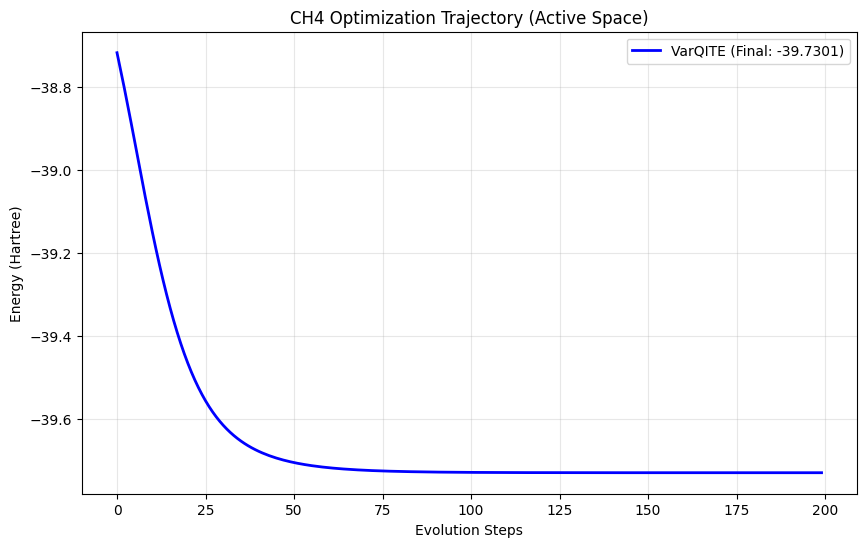

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(energy_history, label=f'VarQITE (Final: {energy_history[-1]:.4f})', color='b', linewidth=2)
plt.title("CH4 Optimization Trajectory (Active Space)")
plt.xlabel("Evolution Steps")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 示例二：使用 VQE 算法求解 H2 分子
本节对比展示经典的 VQE（变分量子本征求解器）算法在 H2 分子上的应用。

### 导入必要的库

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from backends.Tensorcircuit import TensorCircuitBackend
from ansatz.HEA import HEAAnsatz
from solvers.vqe import VQESolver
from chemistry.hamiltonian import Hamiltonian

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

### 分子定义

In [ ]:
# 1. 定义 H2 分子
h2_geometry = [[0.0, 0.0, 0.0], [0.0, 0.0, 0.74]]

# 2. 生成哈密顿量
h_obj_h2 = Hamiltonian(
    symbols=['H', 'H'], 
    geometry=h2_geometry, 
    charge=0, 
    multiplicity=1
)

# 3. 活性空间处理
h_list_h2, n_q_h2, n_e_h2 = h_obj_h2.get_processed_hamiltonian(
    n_active_electrons=2, 
    n_active_orbitals=2
)

print(f"H2 任务: Qubits={n_q_h2}, Electrons={n_e_h2}")

>>> [Hamiltonian] 正在调用 Psi4 计算分子积分...
>>> [Hamiltonian] 设置活性空间: 2e, 2orb
>>> [Hamiltonian] 原始算符项数: 15
H2 任务: Qubits=4, Electrons=2


### 运行 VQE

In [ ]:
# 初始化拟设
ansatz_h2 = HEAAnsatz(n_qubits=n_q_h2, depth=3)
init_params_h2 = torch.randn(ansatz_h2.num_parameters, dtype=torch.float64) * 0.5

# 初始化 VQE 求解器
vqe_solver = VQESolver(backend)

print(">>> 开始运行 VQE (Steps=160, LR=0.1)...")
_, _, vqe_hist = vqe_solver.solve(
    ansatz_h2, 
    init_params_h2, 
    h_list_h2, 
    steps=160, 
    lr=0.1  # 学习率
)

print(f"VQE 最终能量: {vqe_hist[-1]:.6f} Hartree")

>>> 开始运行 VQE (Steps=160, LR=0.1)...
--- VQE Start (Steps=160) ---
VQE Step 0: Energy = 0.130050
VQE Step 20: Energy = -0.905205
VQE Step 40: Energy = -1.099899
VQE Step 60: Energy = -1.115590
VQE Step 80: Energy = -1.116788
VQE Step 100: Energy = -1.117650
VQE Step 120: Energy = -1.119430
VQE Step 140: Energy = -1.125052
VQE Final Energy: -1.133894
VQE 最终能量: -1.133894 Hartree


### VQE 曲线可视化

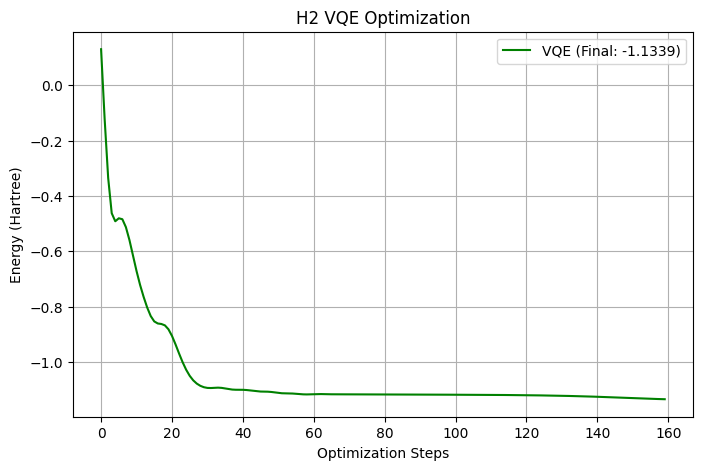

In [68]:
plt.figure(figsize=(8, 5))
plt.plot(vqe_hist, label=f'VQE (Final: {vqe_hist[-1]:.4f})', color='g')
plt.title("H2 VQE Optimization")
plt.xlabel("Optimization Steps")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.grid(True)
plt.show()

## 示例三：使用 VarQITE 和 VQE 方法计算 NH3 分子

### 导入必要的库

In [ ]:
import os
import matplotlib.pyplot as plt
import torch
from backends.Tensorcircuit import TensorCircuitBackend
from ansatz.HEA import HEAAnsatz
from solvers.vqe import VQESolver
from solvers.var_qite import VarQITESolver
from chemistry.hamiltonian import Hamiltonian

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

### 分子定义

In [ ]:
# 1. 定义 NH3 分子 
nh3_geometry = [[0.0, 0.0, 0.1173], [0.0, 0.9397, -0.2641],[0.8138, -0.4699, -0.2641],[-0.8138, -0.4699, -0.2641]]

# 2. 生成哈密顿量
h_obj_nh3 = Hamiltonian(
    symbols=["N", "H", "H", "H"], 
    geometry=nh3_geometry, 
    charge=0, 
    multiplicity=1
)

# 3. 活性空间处理
h_list_nh3, n_q_nh3, n_e_nh3 = h_obj_nh3.get_processed_hamiltonian(
    n_active_electrons=2, 
    n_active_orbitals=2
)

print(f"NH3 任务: Qubits={n_q_h2}, Electrons={n_e_h2}")
print(h_list_h2)

>>> [Hamiltonian] 正在调用 Psi4 计算分子积分...
>>> [Hamiltonian] 设置活性空间: 2e, 2orb
>>> [Hamiltonian] 原始算符项数: 27
NH3 任务: Qubits=4, Electrons=2
[(-54.615242204630604, 'IIII'), (0.13037378276383055, 'ZIII'), (0.13037378276383058, 'IZII'), (-0.21366060378296792, 'IIZI'), (-0.21366060378296792, 'IIIZ'), (0.19175710371636248, 'ZZII'), (-0.0014532280479347386, 'XZXI'), (-0.0014532280479347386, 'YZYI'), (0.11430836776922712, 'ZIZI'), (0.12313315454623103, 'ZIIZ'), (0.12313315454623103, 'IZZI'), (-0.0014532280479347404, 'IXZX'), (-0.0014532280479347404, 'IYZY'), (0.11430836776922712, 'IZIZ'), (0.13219718602256145, 'IIZZ'), (0.01068981661796126, 'ZXZX'), (0.01068981661796126, 'ZYZY'), (0.010689816617961258, 'XIXI'), (0.010689816617961258, 'YIYI'), (-0.0088247867770039, 'XXYY'), (0.0088247867770039, 'XYYX'), (0.0088247867770039, 'YXXY'), (-0.0088247867770039, 'YYXX'), (0.012143044073526663, 'XZXZ'), (0.012143044073526663, 'YZYZ'), (0.012143044073526663, 'IXIX'), (0.012143044073526663, 'IYIY')]


In [ ]:
# 初始化拟设
ansatz_nh3 = HEAAnsatz(n_qubits=n_q_nh3, depth=3)
backend = TensorCircuitBackend()
init_params_nh3 = torch.randn(ansatz_nh3.num_parameters, dtype=torch.float64) * 0.5

# 初始化 VQE 求解器
vqe_solver = VQESolver(backend)

print(">>> 开始运行 VQE (Steps=200, LR=0.2)...")
_, _, vqe_hist = vqe_solver.solve(
    ansatz_nh3, 
    init_params_nh3, 
    h_list_nh3, 
    steps=200, 
    lr=0.2  # 学习率
)

print(f"VQE 最终能量: {vqe_hist[-1]:.6f} Hartree")

>>> 开始运行 VQE (Steps=200, LR=0.2)...
--- VQE Start (Steps=200) ---
VQE Step 0: Energy = -54.602066
VQE Step 20: Energy = -55.437882
VQE Step 40: Energy = -55.450918
VQE Step 60: Energy = -55.453466
VQE Step 80: Energy = -55.454211
VQE Step 100: Energy = -55.454235
VQE Step 120: Energy = -55.454248
VQE Step 140: Energy = -55.454252
VQE Step 160: Energy = -55.454255
VQE Step 180: Energy = -55.454257
VQE Final Energy: -55.454260
VQE 最终能量: -55.454260 Hartree


In [ ]:
var_solver = VarQITESolver(backend)

# 执行演化
final_e_nh3, final_params_nh3, energy_history_nh3, _ = var_solver.solve(
    ansatz_nh3, 
    init_params_nh3, 
    h_list_nh3, 
    total_tau=40.0, 
    delta_tau=0.2, 
    mode='autograd'
)

print(f"求解结束。最终能量: {energy_history_nh3[-1]:.6f} Hartree")

--- VarQITE Start (Mode=autograd, Total Tau=40.0, dt=0.2) ---
Step 0: Energy = -54.369684 (Time: 0.1557s)
Step 10: Energy = -55.133066 (Time: 0.1332s)
Step 20: Energy = -55.336662 (Time: 0.1525s)
Step 30: Energy = -55.424860 (Time: 0.1602s)
Step 40: Energy = -55.448305 (Time: 0.1476s)
Step 50: Energy = -55.453633 (Time: 0.1419s)
Step 60: Energy = -55.454805 (Time: 0.1382s)
Step 70: Energy = -55.455067 (Time: 0.1729s)
Step 80: Energy = -55.455127 (Time: 0.1470s)
Step 90: Energy = -55.455141 (Time: 0.1381s)
Step 100: Energy = -55.455144 (Time: 0.1330s)
Step 110: Energy = -55.455144 (Time: 0.1526s)
Step 120: Energy = -55.455145 (Time: 0.1394s)
Step 130: Energy = -55.455145 (Time: 0.1461s)
Step 140: Energy = -55.455145 (Time: 0.1439s)
Step 150: Energy = -55.455145 (Time: 0.1502s)
Step 160: Energy = -55.455145 (Time: 0.1335s)
Step 170: Energy = -55.455145 (Time: 0.1492s)
Step 180: Energy = -55.455145 (Time: 0.1368s)
Step 190: Energy = -55.455145 (Time: 0.1539s)
Step 199: Energy = -55.455145

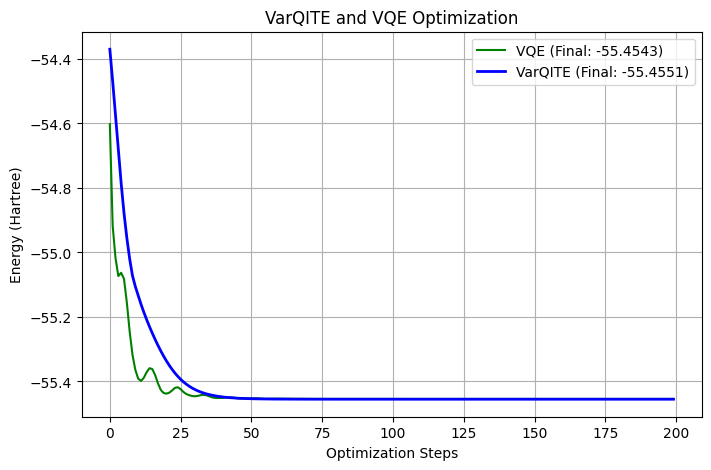

In [70]:
plt.figure(figsize=(8, 5))
plt.plot(vqe_hist, label=f'VQE (Final: {vqe_hist[-1]:.4f})', color='g')
plt.plot(energy_history_nh3, label=f'VarQITE (Final: {energy_history_nh3[-1]:.4f})', color='b', linewidth=2)
plt.title("VarQITE and VQE Optimization")
plt.xlabel("Optimization Steps")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.grid(True)
plt.show()



## 示例四：RMITE 算法求解 N2 分子
简介：RMITE (Random-Measurement Imaginary-Time Evolution) 通过随机测量近似计算量子费舍尔信息矩阵（QFIM），将复杂度从 $O(m^2)$ 降低至 $O(Km)$，适合在近期量子设备上运行。

### 导入必要的库

In [6]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from backends.Tensorcircuit import TensorCircuitBackend
from ansatz.HEA import HEAAnsatz
from solvers.rite import RITESolver
from chemistry.hamiltonian import Hamiltonian

### 定义分子与哈密顿量
定义 $N_2$ 分子的几何构型，并设定活性空间 (2 electrons, 2 orbitals) 以生成哈密顿量。

In [7]:
# 1. 定义 N2 分子坐标
n2_geometry = [
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0977]
]

# 2. 获取哈密顿量
h_obj = Hamiltonian(
    symbols=['N', 'N'],
    geometry=n2_geometry,
    charge=0,
    multiplicity=1
)

# 设定活性空间 (2e, 2orb) -> 对应 4 Qubits
h_list, n_qubits, n_electrons = h_obj.get_processed_hamiltonian(
    n_active_electrons=2, 
    n_active_orbitals=2
)
print(h_list)

>>> [Hamiltonian] 正在调用 Psi4 计算分子积分...
>>> [Hamiltonian] 设置活性空间: 2e, 2orb
>>> [Hamiltonian] 原始算符项数: 15
[(-106.8993464106202, 'IIII'), (0.15516729364604032, 'ZIII'), (0.1551672936460403, 'IZII'), (-0.031043656667881808, 'IIZI'), (-0.031043656667881836, 'IIIZ'), (0.14628420450965096, 'ZZII'), (0.12564006288409704, 'ZIZI'), (0.13519875066624087, 'ZIIZ'), (0.13519875066624087, 'IZZI'), (0.12564006288409704, 'IZIZ'), (0.1512684258620989, 'IIZZ'), (-0.009558687782143832, 'XXYY'), (0.009558687782143832, 'XYYX'), (0.009558687782143832, 'YXXY'), (-0.009558687782143832, 'YYXX')]


### 执行 RMITE 求解
配置求解器参数（采样数、演化时间、步长等）并开始迭代求解。

In [ ]:
# 4. 运行 RITE 求解器
backend = TensorCircuitBackend()
rite_solver = RITESolver(backend)

# n_samples: 采样次数
# total_tau: 演化总时长
final_energy, final_params, energies, _ = rite_solver.solve(
    ansatz, 
    init_params, 
    h_list, 
    total_tau=2000.0,   
    delta_tau=10,     
    n_samples=50,     
    regularization=1e-4 
)

print(f"RITE Final Energy: {final_energy:.6f} Hartree")

--- RITE Start (Samples=50, Total Tau=2000.0, dt=10) ---
RITE Step 0: Energy = -106.695955 (Time: 0.3569s)
RITE Step 2: Energy = -107.060694 (Time: 0.3394s)
RITE Step 4: Energy = -107.261607 (Time: 0.3570s)
RITE Step 6: Energy = -107.343653 (Time: 0.3532s)
RITE Step 8: Energy = -107.384129 (Time: 0.3482s)
RITE Step 10: Energy = -107.411095 (Time: 0.3437s)
RITE Step 12: Energy = -107.428322 (Time: 0.3492s)
RITE Step 14: Energy = -107.443915 (Time: 0.3462s)
RITE Step 16: Energy = -107.455133 (Time: 0.3338s)
RITE Step 18: Energy = -107.464717 (Time: 0.3484s)
RITE Step 20: Energy = -107.471767 (Time: 0.3666s)
RITE Step 22: Energy = -107.477641 (Time: 0.3601s)
RITE Step 24: Energy = -107.482192 (Time: 0.4266s)
RITE Step 26: Energy = -107.485548 (Time: 0.3315s)
RITE Step 28: Energy = -107.488364 (Time: 0.3395s)
RITE Step 30: Energy = -107.490478 (Time: 0.3233s)
RITE Step 32: Energy = -107.492092 (Time: 0.3319s)
RITE Step 34: Energy = -107.493357 (Time: 0.3316s)
RITE Step 36: Energy = -107.49

### 结果可视化
绘制能量随迭代步数的收敛曲线。

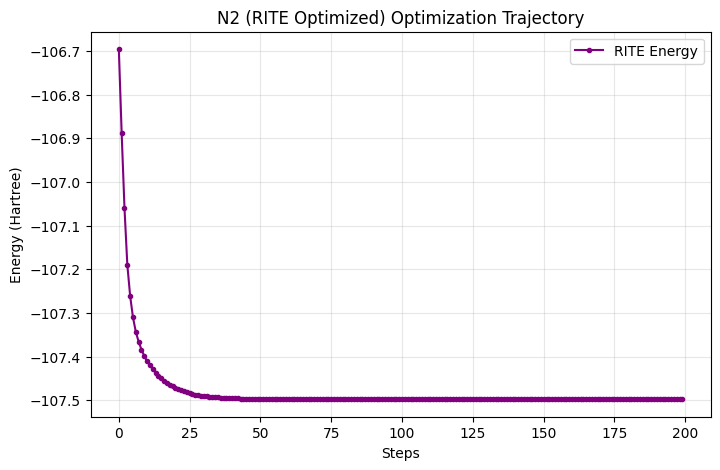

In [74]:
plt.figure(figsize=(8, 5))
plt.plot(energies, label='RITE Energy', marker='o', markersize=3, color='purple')
plt.title("N2 (RITE Optimized) Optimization Trajectory")
plt.xlabel("Steps")
plt.ylabel("Energy (Hartree)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 示例五：SSQITE 算法求解激发态
简介：SSQITE (Subspace-Search QITE) 结合了子空间搜索与虚时演化。通过引入加权机制和变时间步长（$d\tau_j = b/2^j$），它可以在同一个参数化电路中同时分离并求解基态和多个激发态。

### 导入必要的库

In [8]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from backends.Tensorcircuit import TensorCircuitBackend
from backends.core import QuantumCircuit
from solvers import SSQITESolver

### 定义拟设 (Ansatz)
构建一个简单的 Ry-Rz 结构的参数化量子电路。

In [9]:
def notebook_ansatz(params):
    n_qubits = 2
    n_layers = 3
    qc = QuantumCircuit(n_qubits)
    if not isinstance(params, torch.Tensor): 
        params = torch.tensor(params)
    
    idx = 0
    # 初始旋转层
    for i in range(n_qubits):
        qc.ry(i, params[idx]); idx+=1
        qc.rz(i, params[idx]); idx+=1
    
    # 纠缠 + 旋转层
    for _ in range(n_layers):
        if n_qubits > 1: qc.cx(0, 1)
        for i in range(n_qubits):
            qc.ry(i, params[idx]); idx+=1
            qc.rz(i, params[idx]); idx+=1
    return qc

### 定义物理模型 (Ising Model)
定义一个简单的哈密顿量，其理论能级为 $E_0=-2.0, E_1=0.0, E_2=1.0$。

In [10]:
# Ising Model Hamiltonian
hamiltonian = [(0.5, 'II'), (-1.5, 'ZI'), (-1.0, 'IZ')]
n_states = 3 # 求解前3个能级

### 执行 SSQITE 求解
初始化后端，设置步长参数 b_step，运行求解过程。

In [31]:
# 初始化后端
backend = TensorCircuitBackend()
solver = SSQITESolver(backend)

# 初始化参数
init_params = torch.rand(24) * 2 * np.pi 

print(f"--- SSQITE Start: States={n_states} ---")

# 运行求解
final_e, _, history = solver.solve(
    ansatz_func=notebook_ansatz, 
    init_params=init_params, 
    hamiltonian=hamiltonian, 
    n_states=n_states, 
    b_step=0.05, 
    max_steps=100
)

--- SSQITE Start: States=3 ---
--- SSQITE Start: States=3, b=0.05, Steps=100 ---
--- Weights (Time Steps): [0.05, 0.025, 0.0125] ---
Step 0   | Energies: [0.2287, 0.6512, 0.1558] (0.149s)
Step 10  | Energies: [-1.1650, 0.4799, 0.6026] (0.128s)
Step 20  | Energies: [-1.7983, 0.3867, 1.0333] (0.134s)
Step 30  | Energies: [-1.9455, 0.3115, 1.1309] (0.143s)
Step 40  | Energies: [-1.9776, 0.2461, 1.1365] (0.134s)
Step 50  | Energies: [-1.9871, 0.1903, 1.1283] (0.146s)
Step 60  | Energies: [-1.9912, 0.1446, 1.1197] (0.155s)
Step 70  | Energies: [-1.9935, 0.1086, 1.1116] (0.133s)
Step 80  | Energies: [-1.9949, 0.0812, 1.1033] (0.150s)
Step 90  | Energies: [-1.9958, 0.0609, 1.0946] (0.141s)
Step 99  | Energies: [-1.9963, 0.0473, 1.0866] (0.128s)


### 多能级收敛可视化
展示基态和两个激发态的能量演化过程。

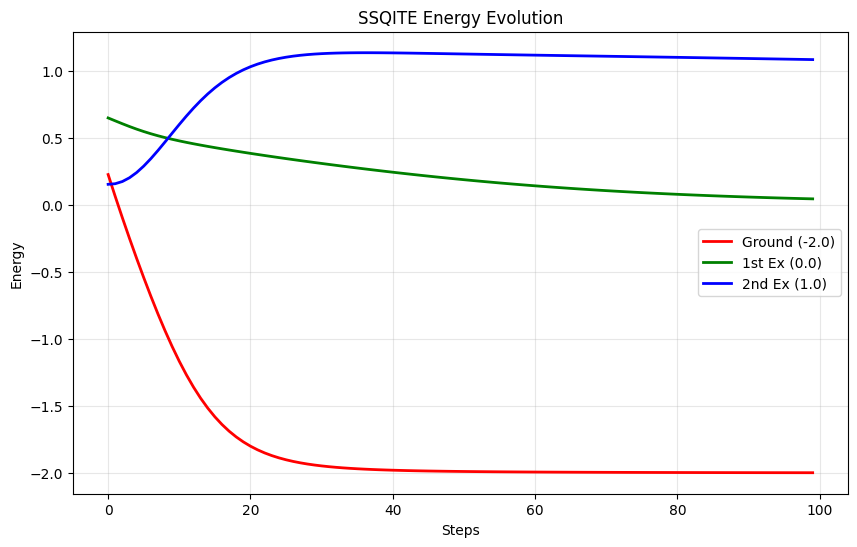

Final Energies: [-1.9963476799993223, 0.04727775231017792, 1.0865563721003257]


In [32]:
history = np.array(history)
plt.figure(figsize=(10, 6))

labels = ['Ground (-2.0)', '1st Ex (0.0)', '2nd Ex (1.0)']
colors = ['red', 'green', 'blue']

for i in range(n_states):
    if i < history.shape[1]:
        plt.plot(history[:, i], label=labels[i], color=colors[i], linewidth=2)
    
plt.title("SSQITE Energy Evolution")
plt.xlabel("Steps")
plt.ylabel("Energy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Energies: {final_e}")